# HTSAT Head Representations — Analysis Notebook

## 0. Imports & Configuration

In [1]:
import torch
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

from tqdm.notebook import tqdm
from collections import defaultdict
from scipy import stats
from scipy.stats import spearmanr, pearsonr, linregress
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from skdim.id import TwoNN, MLE

# ──────────────────────────────────────────────────────────────────────────────
# Configuration
# ──────────────────────────────────────────────────────────────────────────────

DATASET      = "ESC50"          # ESC50 | TinySOL | VocalSound | IRMAS
DATASET_NAME = DATASET.lower()

HTSAT_DEPTHS = [2, 2, 6, 2]
HTSAT_HEADS  = [4, 8, 16, 32]
N_BLOCKS     = sum(HTSAT_DEPTHS)   # 12

COLORS = {
    'layer0': '#2d77a6',
    'layer1': '#bf7b04',
    'layer2': '#6ea66d',
    'layer3': '#808080',
    'accent': '#d62728',
}
layer_colors = {i: COLORS[f'layer{i}'] for i in range(4)}

plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.2)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 13,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.axisbelow': True,
})

# ──────────────────────────────────────────────────────────────────────────────
# Load dataset — classes auto-loaded from dataset file
# ──────────────────────────────────────────────────────────────────────────────

DATASET_CLASS_MAP = {
    'ESC50':      ('datasets.esc50',      'ESC50'),
    'TinySOL':    ('datasets.tinysol',    'TinySOL'),
    'VocalSound': ('datasets.vocalsound', 'VocalSound'),
    'IRMAS':      ('datasets.irmas',      'IRMAS'),
}

import importlib
module_path, class_name = DATASET_CLASS_MAP[DATASET]
mod         = importlib.import_module(module_path)
DatasetCls  = getattr(mod, class_name)
_ds         = DatasetCls(root='../data', download=True)
CLASSES     = _ds.classes          # list of class names
N_CLASSES   = len(CLASSES)

print(f"Dataset : {DATASET}  ({N_CLASSES} classes)")
print(f"Classes : {CLASSES}")
print(f"Depths  : {HTSAT_DEPTHS}  →  {N_BLOCKS} total blocks")

Dataset già presente in ../data/ESC-50-master, skip download.
Loading audio files


100%|██████████| 2000/2000 [00:00<00:00, 14548.86it/s]

✓ Cache di validazione trovata (2026-04-01T21:46:58.127961): 2000 validi, 0 corrotti. Skip validazione.
Dataset : ESC50  (50 classes)
Classes : ['airplane', 'breathing', 'brushing teeth', 'can opening', 'car horn', 'cat', 'chainsaw', 'chirping birds', 'church bells', 'clapping', 'clock alarm', 'clock tick', 'coughing', 'cow', 'crackling fire', 'crickets', 'crow', 'crying baby', 'dog', 'door wood creaks', 'door wood knock', 'drinking sipping', 'engine', 'fireworks', 'footsteps', 'frog', 'glass breaking', 'hand saw', 'helicopter', 'hen', 'insects', 'keyboard typing', 'laughing', 'mouse click', 'pig', 'pouring water', 'rain', 'rooster', 'sea waves', 'sheep', 'siren', 'sneezing', 'snoring', 'thunderstorm', 'toilet flush', 'train', 'vacuum cleaner', 'washing machine', 'water drops', 'wind']
Depths  : [2, 2, 6, 2]  →  12 total blocks


## 1. Load Data

In [2]:
loaded = torch.load(
    f'heads_representations/{DATASET_NAME}_head_outputs_final.pt',
    map_location='cpu',
    weights_only=False,
)
head_outputs_final = loaded['head_outputs_final']
sample_labels      = loaded['labels']

n_samples = len(sample_labels)
n_classes = len(np.unique(sample_labels))

print(f"Loaded {len(head_outputs_final)} heads, {n_samples} samples, {n_classes} classes")
print(f"Class distribution: {np.bincount(sample_labels)}")

Loaded 184 heads, 2000 samples, 50 classes
Class distribution: [40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40
 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40
 40 40]


## 2. Intrinsic Dimensionality Analysis

In [3]:
def compute_intrinsic_dim_metrics(X):
    pca = PCA(n_components=min(X.shape))
    pca.fit(X)
    eigenvalues = pca.explained_variance_
    evr         = pca.explained_variance_ratio_
    evr_cumsum  = np.cumsum(evr)

    metrics = {
        'pca_90':  np.argmax(evr_cumsum >= 0.90) + 1,
        'pca_95':  np.argmax(evr_cumsum >= 0.95) + 1,
        'pca_99':  np.argmax(evr_cumsum >= 0.99) + 1,
        'evr_pc1': evr[0],
        'evr_pc2': evr[1] if len(evr) > 1 else 0,
        'evr_pc3': evr[2] if len(evr) > 2 else 0,
        'pr':      (eigenvalues.sum() ** 2) / (eigenvalues ** 2).sum(),
    }

    try:
        metrics['twonn'] = TwoNN().fit_transform(X)
    except Exception:
        metrics['twonn'] = np.nan

    try:
        metrics['mle'] = MLE().fit_transform(X)
    except Exception:
        metrics['mle'] = np.nan

    evr_norm = evr / evr.sum()
    metrics['shannon_entropy'] = -np.sum(evr_norm * np.log(evr_norm + 1e-10))
    metrics['eff_rank']        = np.exp(metrics['shannon_entropy'])

    return metrics, pca

In [4]:
head_id_results = {}

for head_id, head_repr in tqdm(head_outputs_final.items(), desc="ID Analysis"):
    X       = head_repr.numpy()
    parts   = head_id.split('_')
    metrics, pca = compute_intrinsic_dim_metrics(X)
    head_id_results[head_id] = {
        **metrics,
        'layer':    int(parts[0][1]),
        'block':    int(parts[1][1]),
        'head':     int(parts[2][1]),
        'head_dim': X.shape[1],
    }

id_df     = pd.DataFrame(head_id_results).T.reset_index(names='head_id')
num_cols  = id_df.columns.difference(['head_id'])
id_df[num_cols] = id_df[num_cols].apply(pd.to_numeric, errors='coerce')

print(f"Analysis complete: {len(id_df)} heads")

ID Analysis:   0%|          | 0/184 [00:00<?, ?it/s]

Analysis complete: 184 heads


In [5]:
# Export CSV
id_df[['head_id', 'pca_90', 'pca_95', 'pca_99', 'evr_pc1', 'evr_pc2',
       'pr', 'twonn', 'mle', 'shannon_entropy', 'eff_rank']
].round(2).to_csv(DATASET + '_id_df.csv', index=False)
print("Saved: id_df.csv")

Saved: id_df.csv


## 3. Block-wise Metrics Visualization

In [6]:
def get_global_block(row):
    return sum(HTSAT_DEPTHS[:int(row['layer'])]) + int(row['block'])

id_df['global_block'] = id_df.apply(get_global_block, axis=1)

layer_boundaries_idx = [sum(HTSAT_DEPTHS[:i]) for i in range(1, len(HTSAT_DEPTHS))]

block_metrics_rows = []
for b in range(N_BLOCKS):
    bd = id_df[id_df['global_block'] == b]
    if bd.empty:
        continue
    block_metrics_rows.append({
        'Block': b,
        'L':     bd['pca_99'].mean(),
        'N':     bd['twonn'].mean(),
        'Ratio': bd['pca_99'].mean() / bd['twonn'].mean() if bd['twonn'].mean() > 0 else np.nan,
        'EVR1':  bd['evr_pc1'].mean(),
        'Layer': bd['layer'].iloc[0],
    })

metrics_df_block = pd.DataFrame(block_metrics_rows)

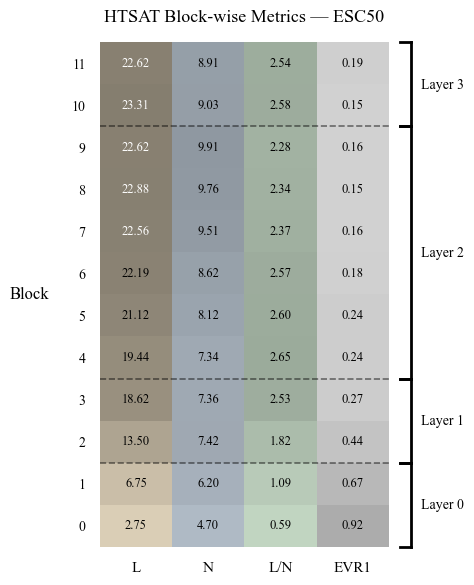

In [7]:
fig, ax = plt.subplots(figsize=(5, N_BLOCKS * 0.5))

columns  = ['L', 'N', 'L/N', 'EVR1']
data     = metrics_df_block[['L', 'N', 'Ratio', 'EVR1']].values
max_vals = {'L': 25, 'N': 15, 'L/N': 5, 'EVR1': 2}
palette  = {
    'L':    np.array([0.9,  0.85, 0.75]),
    'N':    np.array([0.8,  0.85, 0.9 ]),
    'L/N':  np.array([0.8,  0.88, 0.8 ]),
    'EVR1': np.array([0.85, 0.85, 0.85]),
}

for i in range(N_BLOCKS):
    for j, col_name in enumerate(columns):
        val = data[i, j]
        if np.isnan(val):
            continue
        norm       = val / max_vals[col_name]
        face_color = palette[col_name] * (1 - 0.45 * norm)
        ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=face_color, edgecolor=None))
        text_color = 'white' if np.mean(face_color) < 0.5 else 'black'
        ax.text(j + 0.5, i + 0.5, f"{val:.2f}",
                ha='center', va='center', fontsize=9, fontweight='bold', color=text_color)

ax.set_xlim(0, len(columns))
ax.set_ylim(0, N_BLOCKS)
ax.set_xticks(np.arange(len(columns)) + 0.5)
ax.set_xticklabels(columns, fontsize=11, fontweight='bold')
ax.set_yticks(np.arange(N_BLOCKS) + 0.5)
ax.set_yticklabels([str(b) for b in range(N_BLOCKS)], fontsize=10)

cum_boundary = [0] + [sum(HTSAT_DEPTHS[:i+1]) for i in range(len(HTSAT_DEPTHS))]
for boundary in cum_boundary[1:-1]:
    ax.axhline(y=boundary, color='k', linewidth=1.2, linestyle='--', alpha=0.5)

bracket_x = len(columns) + 0.3
for layer_idx in range(len(HTSAT_DEPTHS)):
    y_start = cum_boundary[layer_idx]
    y_end   = cum_boundary[layer_idx + 1]
    y_mid   = (y_start + y_end) / 2
    ax.plot([bracket_x, bracket_x], [y_start, y_end], 'k-', linewidth=2, clip_on=False)
    ax.plot([bracket_x, bracket_x - 0.15], [y_start, y_start], 'k-', linewidth=2, clip_on=False)
    ax.plot([bracket_x, bracket_x - 0.15], [y_end,   y_end  ], 'k-', linewidth=2, clip_on=False)
    layer_num = len(HTSAT_DEPTHS) - layer_idx
    ax.text(bracket_x + 0.15, y_mid, f'Layer {5 - layer_num - 1}',
            ha='left', va='center', fontsize=10, fontweight='bold', clip_on=False)

ax.set_ylabel('Block', fontsize=12, fontweight='bold', rotation=0, labelpad=30, va='center')
ax.set_title('HTSAT Block-wise Metrics — ' + DATASET, fontsize=13, fontweight='bold', pad=15)
ax.tick_params(left=False, top=False, bottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('htsat_' + DATASET + '_block_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## 4. Dimensionality Metric Panels (A–G)

In [8]:
x_pos          = np.arange(len(id_df))
legend_patches = [mpatches.Patch(facecolor=layer_colors[l], alpha=0.7, label=f'Layer {l}')
                  for l in range(4)]

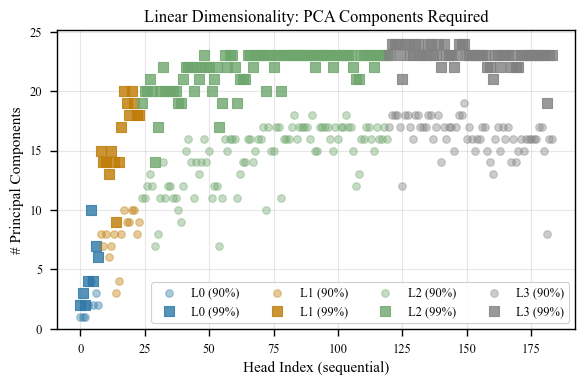

In [9]:
# Panel A — PCA components required
fig, ax = plt.subplots(figsize=(6, 4))
for layer in range(4):
    mask = id_df['layer'] == layer
    ax.scatter(x_pos[mask], id_df.loc[mask, 'pca_90'],
               c=layer_colors[layer], alpha=0.4, s=30, marker='o', label=f'L{layer} (90%)')
    ax.scatter(x_pos[mask], id_df.loc[mask, 'pca_99'],
               c=layer_colors[layer], alpha=0.8, s=50, marker='s', label=f'L{layer} (99%)')
ax.set_xlabel('Head Index (sequential)')
ax.set_ylabel('# Principal Components')
ax.set_title('Linear Dimensionality: PCA Components Required')
ax.legend(ncol=4, loc='lower right', framealpha=0.9)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('panel_A_pca_components.png', dpi=300)
plt.show()

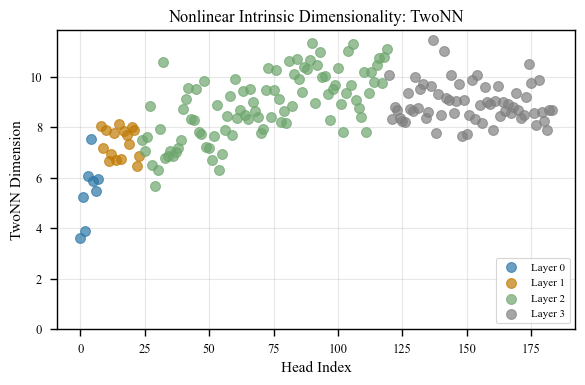

In [10]:
# Panel B — TwoNN
fig, ax = plt.subplots(figsize=(6, 4))
for layer in range(4):
    mask = id_df['layer'] == layer
    ax.scatter(x_pos[mask], id_df.loc[mask, 'twonn'],
               c=layer_colors[layer], alpha=0.7, s=50, label=f'Layer {layer}')
ax.set_xlabel('Head Index')
ax.set_ylabel('TwoNN Dimension')
ax.set_title('Nonlinear Intrinsic Dimensionality: TwoNN')
ax.set_ylim(bottom=0)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('panel_B_twonn.png', dpi=300)
plt.show()

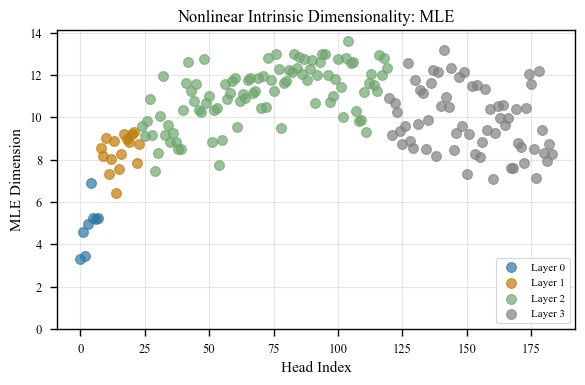

In [11]:
# Panel C — MLE
fig, ax = plt.subplots(figsize=(6, 4))
for layer in range(4):
    mask = id_df['layer'] == layer
    ax.scatter(x_pos[mask], id_df.loc[mask, 'mle'],
               c=layer_colors[layer], alpha=0.7, s=50, label=f'Layer {layer}')
ax.set_xlabel('Head Index')
ax.set_ylabel('MLE Dimension')
ax.set_title('Nonlinear Intrinsic Dimensionality: MLE')
ax.set_ylim(bottom=0)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('panel_C_mle.png', dpi=300)
plt.show()

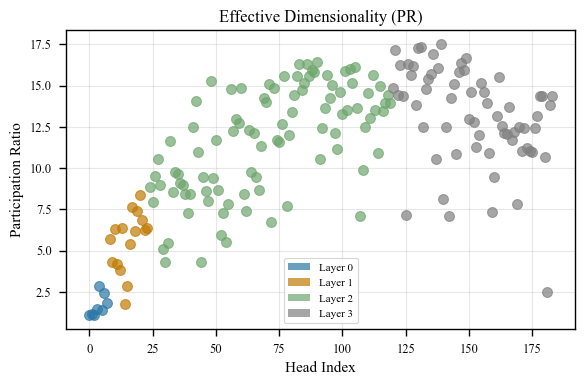

In [12]:
# Panel D — Participation Ratio
fig, ax = plt.subplots(figsize=(6, 4))
for layer in range(4):
    ld = id_df[id_df['layer'] == layer]
    ax.scatter(x_pos[id_df['layer'] == layer], ld['pr'],
               c=layer_colors[layer], alpha=0.7, s=50)
ax.set_xlabel('Head Index')
ax.set_ylabel('Participation Ratio')
ax.set_title('Effective Dimensionality (PR)')
ax.legend(handles=legend_patches, fontsize=8, loc='lower center')
plt.tight_layout()
plt.savefig('panel_D_participation_ratio.png', dpi=300)
plt.show()

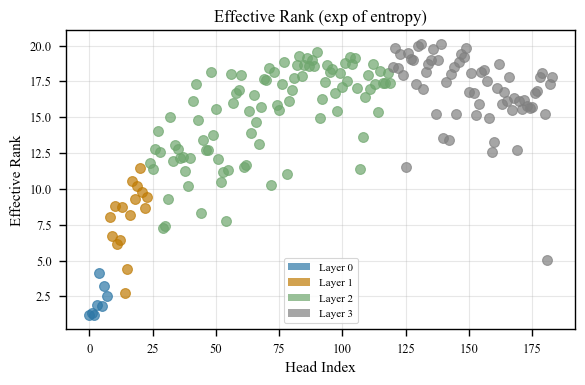

In [13]:
# Panel E — Effective Rank
fig, ax = plt.subplots(figsize=(6, 4))
for layer in range(4):
    ld = id_df[id_df['layer'] == layer]
    ax.scatter(x_pos[id_df['layer'] == layer], ld['eff_rank'],
               c=layer_colors[layer], alpha=0.7, s=50)
ax.set_xlabel('Head Index')
ax.set_ylabel('Effective Rank')
ax.set_title('Effective Rank (exp of entropy)')
ax.legend(handles=legend_patches, fontsize=8, loc='lower center')
plt.tight_layout()
plt.savefig('panel_E_effective_rank.png', dpi=300)
plt.show()

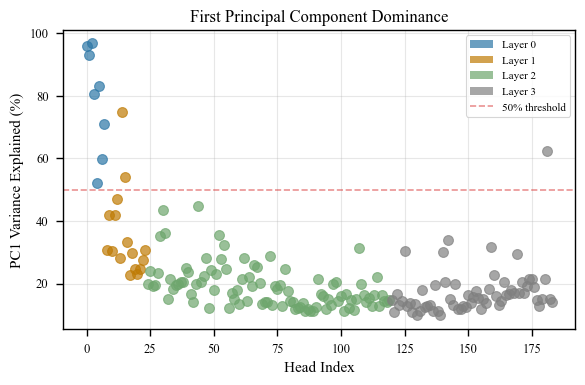

In [14]:
# Panel F — PC1 Dominance
fig, ax = plt.subplots(figsize=(6, 4))
for layer in range(4):
    ld = id_df[id_df['layer'] == layer]
    ax.scatter(x_pos[id_df['layer'] == layer], ld['evr_pc1'] * 100,
               c=layer_colors[layer], alpha=0.7, s=50)
threshold_line = ax.axhline(y=50, color=COLORS['accent'], linestyle='--',
                             alpha=0.5, label='50% threshold')
ax.legend(handles=legend_patches + [threshold_line], fontsize=8)
ax.set_xlabel('Head Index')
ax.set_ylabel('PC1 Variance Explained (%)')
ax.set_title('First Principal Component Dominance')
plt.tight_layout()
plt.savefig('panel_F_pc1_dominance.png', dpi=300)
plt.show()

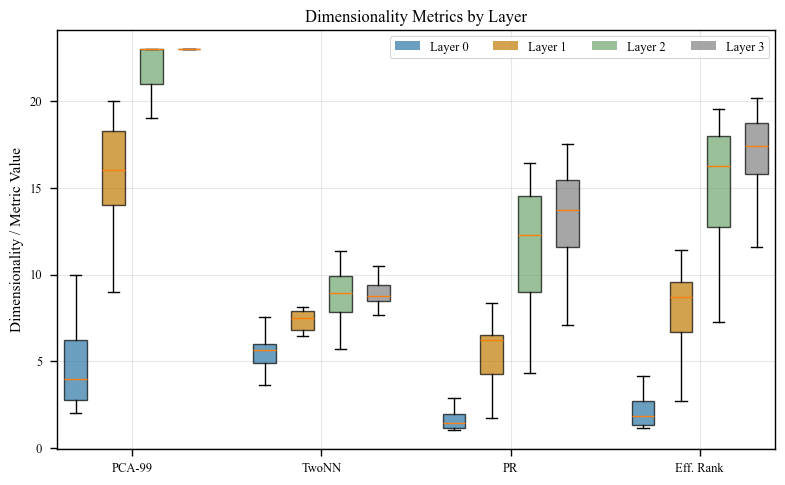

In [15]:
# Panel G — Boxplot comparison across layers
metrics_to_plot = ['pca_99', 'twonn', 'pr', 'eff_rank']
fig, ax = plt.subplots(figsize=(8, 5))

positions, colors_list, data_to_plot = [], [], []
for i, metric in enumerate(metrics_to_plot):
    for layer in range(4):
        layer_data = id_df[id_df['layer'] == layer][metric].dropna()
        positions.append(i * 5 + layer)
        colors_list.append(layer_colors[layer])
        data_to_plot.append(layer_data)

bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6,
                patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks([i * 5 + 1.5 for i in range(len(metrics_to_plot))])
ax.set_xticklabels(['PCA-99', 'TwoNN', 'PR', 'Eff. Rank'])
ax.set_ylabel('Dimensionality / Metric Value')
ax.set_title('Dimensionality Metrics by Layer')
ax.legend(handles=legend_patches, loc='upper right', ncol=4)
plt.tight_layout()
plt.savefig('panel_G_boxplot.png', dpi=300)
plt.show()

## 5. Class-Conditional Activation Heatmap

In [16]:
# Block representations: mean over heads
block_to_heads = defaultdict(list)
block_layer    = {}
global_b = 0
for layer_idx, depth in enumerate(HTSAT_DEPTHS):
    for block_idx in range(depth):
        for head_idx in range(HTSAT_HEADS[layer_idx]):
            block_to_heads[global_b].append(f"L{layer_idx}_B{block_idx}_H{head_idx}")
        block_layer[global_b] = layer_idx
        global_b += 1

block_representations = {
    b: np.stack(
        [head_outputs_final[hid].numpy() for hid in block_to_heads[b]], axis=0
    ).mean(axis=0)
    for b in range(N_BLOCKS)
}

layer_boundaries_plot = []
cum = 0
for d in HTSAT_DEPTHS[:-1]:
    cum += d
    layer_boundaries_plot.append(cum - 0.5)

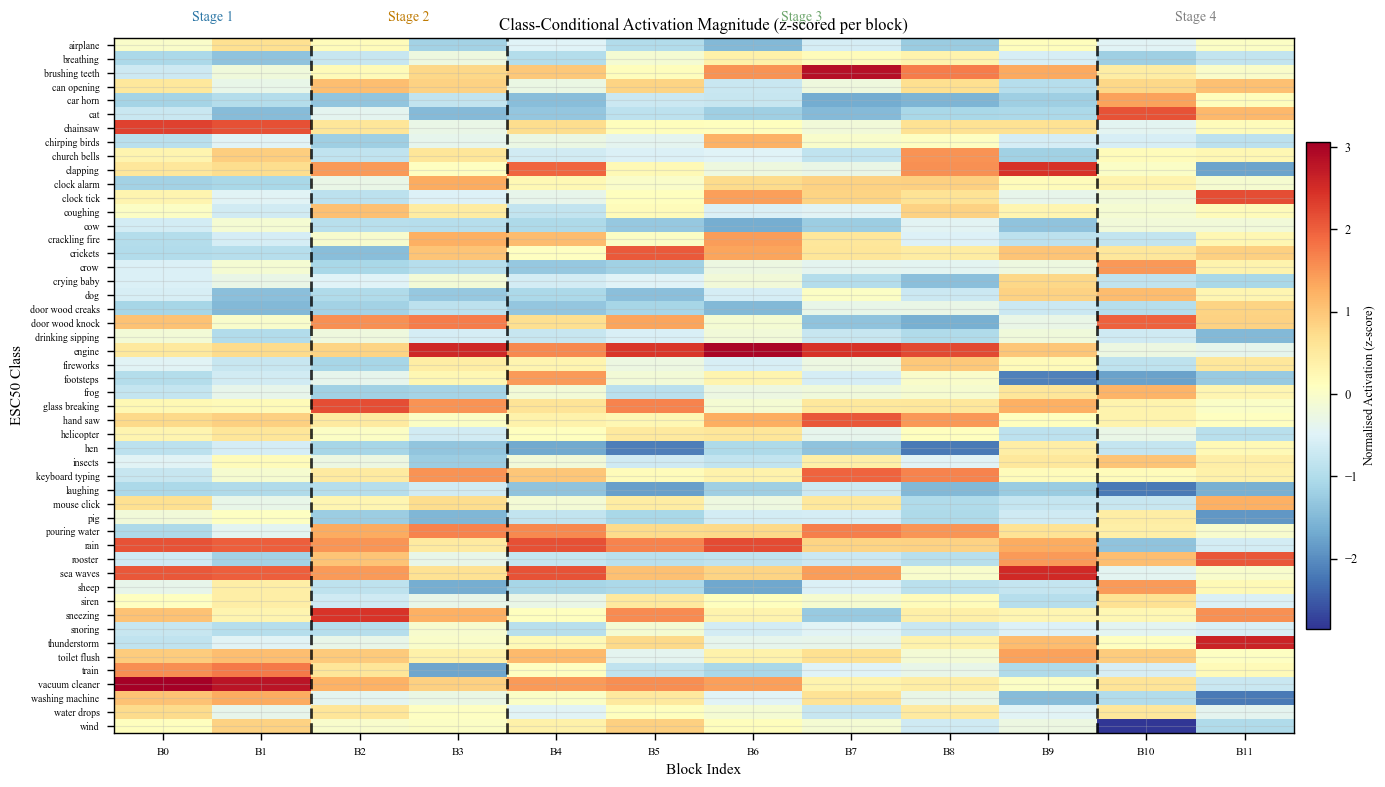

In [17]:
heatmap = np.zeros((n_classes, N_BLOCKS))
for b in range(N_BLOCKS):
    X = block_representations[b]
    for c in range(n_classes):
        heatmap[c, b] = np.linalg.norm(X[sample_labels == c].mean(axis=0))

heatmap_norm = (heatmap - heatmap.mean(axis=0, keepdims=True)) / \
               (heatmap.std(axis=0, keepdims=True) + 1e-8)

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(heatmap_norm, aspect='auto', cmap='RdYlBu_r', interpolation='nearest')

for boundary in layer_boundaries_plot:
    ax.axvline(x=boundary, color='black', linewidth=2, linestyle='--', alpha=0.8)

cum = 0
for layer_idx, depth in enumerate(HTSAT_DEPTHS):
    ax.text(cum + depth / 2 - 0.5, -1.5, f'Stage {layer_idx+1}',
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            color=layer_colors[layer_idx])
    cum += depth

ax.set_xticks(range(N_BLOCKS))
ax.set_xticklabels([f'B{b}' for b in range(N_BLOCKS)], fontsize=8)
ax.set_yticks(range(n_classes))
ax.set_yticklabels(CLASSES[:n_classes], fontsize=7)
ax.set_xlabel('Block Index', fontsize=11)
ax.set_ylabel(f'{DATASET} Class', fontsize=11)
ax.set_title('Class-Conditional Activation Magnitude (z-scored per block)',
             fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01).set_label(
    'Normalised Activation (z-score)', fontsize=9)
plt.tight_layout()
plt.savefig('class_activation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Head Semantic Specialization via OMP on PC1

Analogo dell'esperimento TextSpan / OMP1 del paper ResiDual, adattato al
dominio audio con CLAP. Per ogni testa:
  1. Si calcola la PC1 delle sue rappresentazioni.
  2. Si proiettano i campioni su PC1 → score scalare per campione.
  3. Si usa tale score come peso per fare una media pesata degli embedding
     CLAP audio → "direzione semantica" della testa nello spazio CLAP.
  4. Si lancia OMP greedy sul dizionario di descrizioni testuali CLAP per
     trovare le k etichette più allineate con quella direzione.
  5. Si misura la coerenza interna delle etichette selezionate (Z-score).

In [18]:
# ── Dizionario di descrizioni audio ──────────────────────────────────────────
# Le categorie sono adattate ai 4 dataset (ESC50, IRMAS, TinySOL, VocalSound).
# Arricchisci o restringi le voci secondo il dataset in uso.

AUDIO_DESCRIPTIONS = {
    "animals": [
        "dog barking", "cat meowing", "bird chirping", "frog croaking",
        "rooster crowing", "cow mooing", "insects buzzing", "sheep bleating",
        "crow cawing"
    ],

    "nature": [
        "rain falling", "ocean waves", "wind blowing", "thunder crashing",
        "water dripping", "crackling fire", "crickets at night",
        "water stream flowing", "storm wind"
    ],

    "human_body": [
        "baby crying", "person sneezing", "people clapping", "person laughing",
        "person coughing", "footsteps walking", "person breathing",
        "snoring", "teeth brushing"
    ],

    "human_voice": [
        "singing voice", "spoken words", "humming melody",
        "whispering voice", "shouting voice", "crowd talking",
        "chanting voices", "vocal harmony"
    ],

    "music_strings": [
        "guitar playing", "violin bowing", "cello playing",
        "bass guitar", "harp strumming", "mandolin picking"
    ],

    "music_winds": [
        "flute melody", "trumpet playing", "saxophone sound",
        "clarinet playing", "trombone slide", "oboe tone"
    ],

    "music_keys": [
        "piano melody", "organ playing", "accordion sound",
        "harpsichord playing", "synthesizer tone"
    ],

    "music_percuss": [
        "drum beat", "cymbal crash", "bass drum hit",
        "snare drum roll", "xylophone melody", "percussive rhythm"
    ],

    "urban": [
        "car engine running", "car horn honking", "siren wailing",
        "train passing", "helicopter flying", "airplane overhead",
        "chainsaw cutting", "construction noise", "traffic noise"
    ],

    "indoor": [
        "keyboard typing", "mouse click", "door knock", "clock ticking",
        "vacuum cleaner", "washing machine", "glass breaking",
        "can opening", "door creaking"
    ],

    "acoustic_low": [
        "low frequency rumble", "deep bass tone", "subwoofer vibration",
        "engine drone", "distant thunder", "low hum"
    ],

    "acoustic_high": [
        "high pitched tone", "sharp transient click", "whistle sound",
        "glass ringing", "bird tweet high", "short impulse sound"
    ],

    "texture": [
        "smooth continuous sound", "rough noisy texture",
        "periodic repetition", "irregular pattern",
        "reverberant space", "dry anechoic sound",
        "echo in a room", "outdoor ambient sound"
    ],

    "timbre": [
        "bright metallic sound", "warm resonant tone", "hollow wooden sound",
        "sharp attack fast decay", "slow attack long sustain",
        "muffled dampened sound", "distorted electric sound"
    ],
}

all_descriptions = [desc for descs in AUDIO_DESCRIPTIONS.values() for desc in descs]
desc_categories  = [cat  for cat, descs in AUDIO_DESCRIPTIONS.items() for _ in descs]
cat_list         = list(AUDIO_DESCRIPTIONS.keys())

print(f"Dictionary: {len(all_descriptions)} descriptions, {len(cat_list)} categories")

Dictionary: 103 descriptions, 14 categories


In [19]:
# ── Carica CLAP e codifica il dizionario testuale ────────────────────────────

from CLAPWrapper import CLAPWrapper

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
wrapper = CLAPWrapper(version='2023', use_cuda=torch.cuda.is_available())

emb_dir = "embeddings"
os.makedirs(emb_dir, exist_ok=True)

# File paths (puoi versionarli se vuoi)
text_emb_path  = os.path.join(emb_dir, "text_emb_clap.npy")
audio_emb_path = os.path.join(emb_dir, f"audio_emb_clap_{n_samples}.npy")


# ─────────────────────────────────────────────────────────────────────────────
# TEXT EMBEDDINGS (with caching)
# ─────────────────────────────────────────────────────────────────────────────

if os.path.exists(text_emb_path):
    print("📥 Loading cached TEXT embeddings...")
    text_emb_np = np.load(text_emb_path)

else:
    print("⚙️ Computing TEXT embeddings...")

    with torch.no_grad():
        text_embeddings_dict = wrapper.get_text_embeddings(all_descriptions)

    text_emb_np = text_embeddings_dict.cpu().numpy()
    text_emb_np /= (np.linalg.norm(text_emb_np, axis=1, keepdims=True) + 1e-8)

    np.save(text_emb_path, text_emb_np)
    print(f"💾 Saved TEXT embeddings → {text_emb_path}")

print(f"Text embeddings: {text_emb_np.shape} (n_desc × D_clap)")

⚙️ Computing TEXT embeddings...
💾 Saved TEXT embeddings → embeddings/text_emb_clap.npy
Text embeddings: (103, 1024) (n_desc × D_clap)


In [20]:
# ── Embedding CLAP audio per tutti i campioni (eseguito una volta sola) ───────

# ─────────────────────────────────────────────────────────────────────────────
# AUDIO EMBEDDINGS (with caching)
# ─────────────────────────────────────────────────────────────────────────────

if os.path.exists(audio_emb_path):
    print("📥 Loading cached AUDIO embeddings...")
    audio_emb_matrix = np.load(audio_emb_path)

else:
    print("⚙️ Preparing dataset for AUDIO embeddings...")

    # Carica dataset
    _ds_full = DatasetCls(root='../data', download=False)

    # Ricostruisci sample_list (stratified)
    samples_per_class = len(_ds_full) // len(_ds_full.classes)
    class_buckets_audio = defaultdict(list)

    for idx in range(len(_ds_full)):
        audio_path, class_name, one_hot = _ds_full[idx]

        class_idx = (
            torch.argmax(one_hot).item()
            if hasattr(one_hot, 'item')
            else int(one_hot)
        )

        if len(class_buckets_audio[class_idx]) < samples_per_class:
            class_buckets_audio[class_idx].append((audio_path, class_idx))

        if (
            len(class_buckets_audio) == len(_ds_full.classes)
            and all(len(v) >= samples_per_class for v in class_buckets_audio.values())
        ):
            break

    sample_list_audio = []
    for class_idx in sorted(class_buckets_audio.keys()):
        sample_list_audio.extend(class_buckets_audio[class_idx])

    assert len(sample_list_audio) == n_samples, \
        f"Sample count mismatch: {len(sample_list_audio)} vs {n_samples}"

    print(f"⚙️ Computing AUDIO embeddings for {n_samples} samples...")

    audio_embeddings_clap = []
    with torch.no_grad():
        for audio_path, _ in tqdm(sample_list_audio, desc="CLAP audio emb"):
            emb = wrapper.get_audio_embeddings([audio_path], resample=True)
            audio_embeddings_clap.append(emb.squeeze(0).cpu().numpy())

    audio_emb_matrix = np.stack(audio_embeddings_clap)
    audio_emb_matrix /= np.linalg.norm(audio_emb_matrix, axis=1, keepdims=True) + 1e-8

    np.save(audio_emb_path, audio_emb_matrix)
    print(f"💾 Saved AUDIO embeddings → {audio_emb_path}")

print(f"Audio embeddings matrix: {audio_emb_matrix.shape}")

📥 Loading cached AUDIO embeddings...
Audio embeddings matrix: (2000, 1024)


In [21]:
# ── OMP greedy sul dizionario testuale ───────────────────────────────────────

def omp_top_k(query_vec, dictionary, k=5):
    """
    Greedy Orthogonal Matching Pursuit (OMP).

    query_vec  : (d,) vettore audio query normalizzato
    dictionary : (n, d) dizionario di atomi testuali (righe normalizzate)
    
    Ritorna:
        selected_idx   : indici dei k atomi selezionati
        selected_scores: similarità (prodotto scalare) con il residuo
    """

    # Inizialmente il residuo è uguale alla query
    residual = query_vec.copy()

    # Lista degli indici selezionati
    selected_idx = []

    # Lista degli score (similarità con il residuo)
    selected_scores = []

    # Iterazione greedy: selezioniamo un atomo alla volta
    for _ in range(k):

        # 1. Calcolo similarità tra residuo e tutti gli atomi
        sims = dictionary @ residual
        # shape: (n,)
        # ogni valore = quanto un atomo spiega il residuo

        # 2. Selezione dell'atomo più allineato (in valore assoluto)
        best_idx = int(np.argmax(np.abs(sims)))

        # Salviamo indice e score (con segno!)
        selected_idx.append(best_idx)
        selected_scores.append(float(sims[best_idx]))

        # 3. Aggiorniamo il residuo (proiezione ortogonale)
        atom = dictionary[best_idx]

        # Sottraiamo la componente lungo l'atomo selezionato
        residual = residual - (residual @ atom) * atom

        # 4. Normalizzazione del residuo
        norm = np.linalg.norm(residual)

        # Se il residuo è ~0, abbiamo spiegato tutto → stop
        if norm < 1e-8:
            break

        # Normalizziamo per mantenere stabilità numerica
        residual /= norm

    # Output finale
    return selected_idx, selected_scores

# ── Z-score di coerenza interna ───────────────────────────────────────────────

def coherence_zscore(selected_indices, all_text_emb):
    """
    Misura quanto le descrizioni selezionate si somiglino tra loro
    rispetto alla similarità media con il dizionario intero.
    """
    sel_emb = all_text_emb[selected_indices]
    k = len(selected_indices)
    if k < 2:
        return 0.0
    sim_mat  = sel_emb @ sel_emb.T

    # Sottraiamo la diagonale cosi prendiamo solo le coppie di embedding diversi, e poi facciamo la media.
    intra    = (sim_mat.sum() - np.diag(sim_mat).sum()) / (k * (k - 1))

    # Stessa cosa per l'altra matrice di embeddings (dal resto del dataset)
    all_sims = sel_emb @ all_text_emb.T
    mu_all   = all_sims.mean()
    sigma_all = all_sims.std() + 1e-8

    # Restituiamo uno z-score che misura quanto la similarità interna
    # del sottoinsieme selezionato sia sopra o sotto la media globale.
    return float((intra - mu_all) / sigma_all)

In [22]:
# ── Calcolo per tutte le teste ────────────────────────────────────────────────

K_OMP = 5   # descrizioni selezionate per testa

head_semantic_results = {}

for head_id in tqdm(sorted(head_outputs_final.keys()), desc="OMP per testa"):
    X     = head_outputs_final[head_id].numpy()      # (N_samples, head_dim)
    pca_h = PCA(n_components=min(10, X.shape[1]))
    pca_h.fit(X)

    # Score di ogni campione lungo PC1
    pc1_scores = pca_h.transform(X)[:, 0]            # (N_samples,)

    # Direzione semantica = media pesata degli embedding CLAP audio
    # i pesi (positivi o negativi) che indicano quanto ogni campione contribuisce alla costruzione della direzione semantica della testa
    weights = pc1_scores - pc1_scores.mean()
    if np.std(weights) < 1e-8:
        continue
    weights /= np.linalg.norm(weights)
    semantic_dir  = weights @ audio_emb_matrix        # (D_clap,)
    norm_sd = np.linalg.norm(semantic_dir)
    if norm_sd < 1e-8:
        continue
    semantic_dir /= norm_sd

    # OMP sul dizionario testuale
    idxs, scores = omp_top_k(semantic_dir, text_emb_np, k=K_OMP)
    z            = coherence_zscore(idxs, text_emb_np)
    dom_cat      = pd.Series([desc_categories[i] for i in idxs]).mode()[0]

    head_semantic_results[head_id] = {
        'descriptions': [all_descriptions[i] for i in idxs],
        'categories':   [desc_categories[i]  for i in idxs],
        'scores':       scores,
        'pc1_var':      float(pca_h.explained_variance_ratio_[0]),
        'dominant_cat': dom_cat,
        'coherence_z':  z,
    }

print(f"Semantic analysis complete for {len(head_semantic_results)} heads")

OMP per testa:   0%|          | 0/184 [00:00<?, ?it/s]

Semantic analysis complete for 184 heads


In [23]:
# ── DataFrame riassuntivo ─────────────────────────────────────────────────────

sem_df = pd.DataFrame([
    {
        'head_id':      hid,
        'layer':        int(hid.split('_')[0][1:]),
        'block':        int(hid.split('_')[1][1:]),
        'head':         int(hid.split('_')[2][1:]),
        'dominant_cat': r['dominant_cat'],
        'coherence_z':  r['coherence_z'],
        'pc1_var':      r['pc1_var'],
        'descriptions': r['descriptions'],
        'categories':   r['categories'],
        'scores':       r['scores'],
    }
    for hid, r in head_semantic_results.items()
])
sem_df['global_block'] = sem_df.apply(get_global_block, axis=1)
sem_df = sem_df.sort_values('coherence_z', ascending=False).reset_index(drop=True)

print(f"\nTop-15 teste più specializzate (Z-score coerenza):")
print(sem_df[['head_id', 'layer', 'dominant_cat', 'coherence_z',
              'pc1_var', 'descriptions']].head(15).to_string())


Top-15 teste più specializzate (Z-score coerenza):
      head_id  layer   dominant_cat  coherence_z   pc1_var                                                                                 descriptions
0    L3_B0_H7      3     human_body     1.577244  0.138146                      [baby crying, car engine running, baby crying, cow mooing, baby crying]
1    L2_B4_H1      2     human_body     1.464484  0.113437        [person sneezing, keyboard typing, person coughing, people clapping, person sneezing]
2   L2_B5_H15      2         nature     1.236646  0.148025           [water dripping, crow cawing, water dripping, bird chirping, water stream flowing]
3   L3_B0_H25      3         nature     1.190981  0.199190                 [water dripping, crow cawing, water dripping, clock ticking, teeth brushing]
4   L3_B1_H16      3     human_body     1.059199  0.168799       [person coughing, car engine running, person sneezing, door creaking, person sneezing]
5   L3_B1_H20      3     human_body 

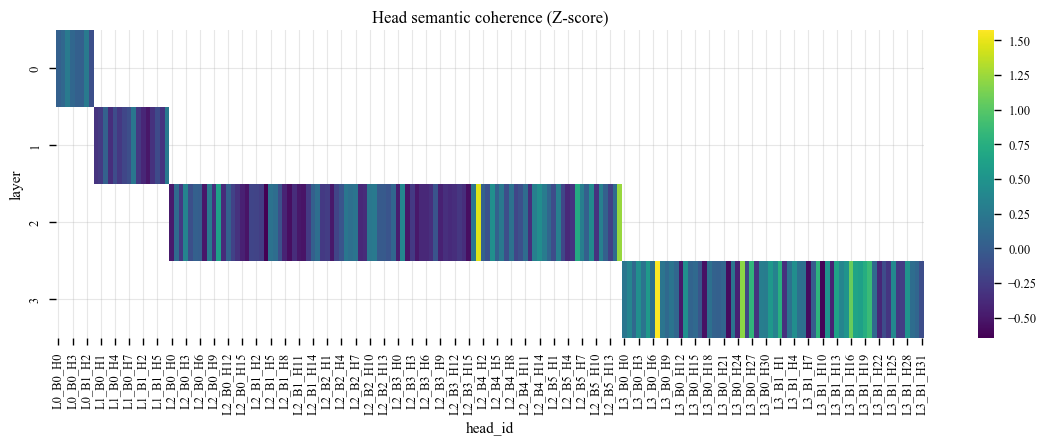

In [24]:
sem_df_sorted = sem_df.sort_values(['layer', 'block', 'head']).reset_index(drop=True)
pivot = sem_df_sorted.pivot(index="layer", columns="head_id", values="coherence_z")

# Riordina le colonne con key numerica invece che lessicografica
col_order = sorted(pivot.columns, key=lambda x: (
    int(x.split('_')[0][1:]),   # layer
    int(x.split('_')[1][1:]),   # block
    int(x.split('_')[2][1:])    # head
))
pivot = pivot[col_order]

plt.figure(figsize=(14,4))
sns.heatmap(pivot, cmap="viridis")
plt.title("Head semantic coherence (Z-score)")
plt.savefig('head_semantic_coherence.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.1 Report qualitativo — top head per layer (analogo Figura 3 del paper)

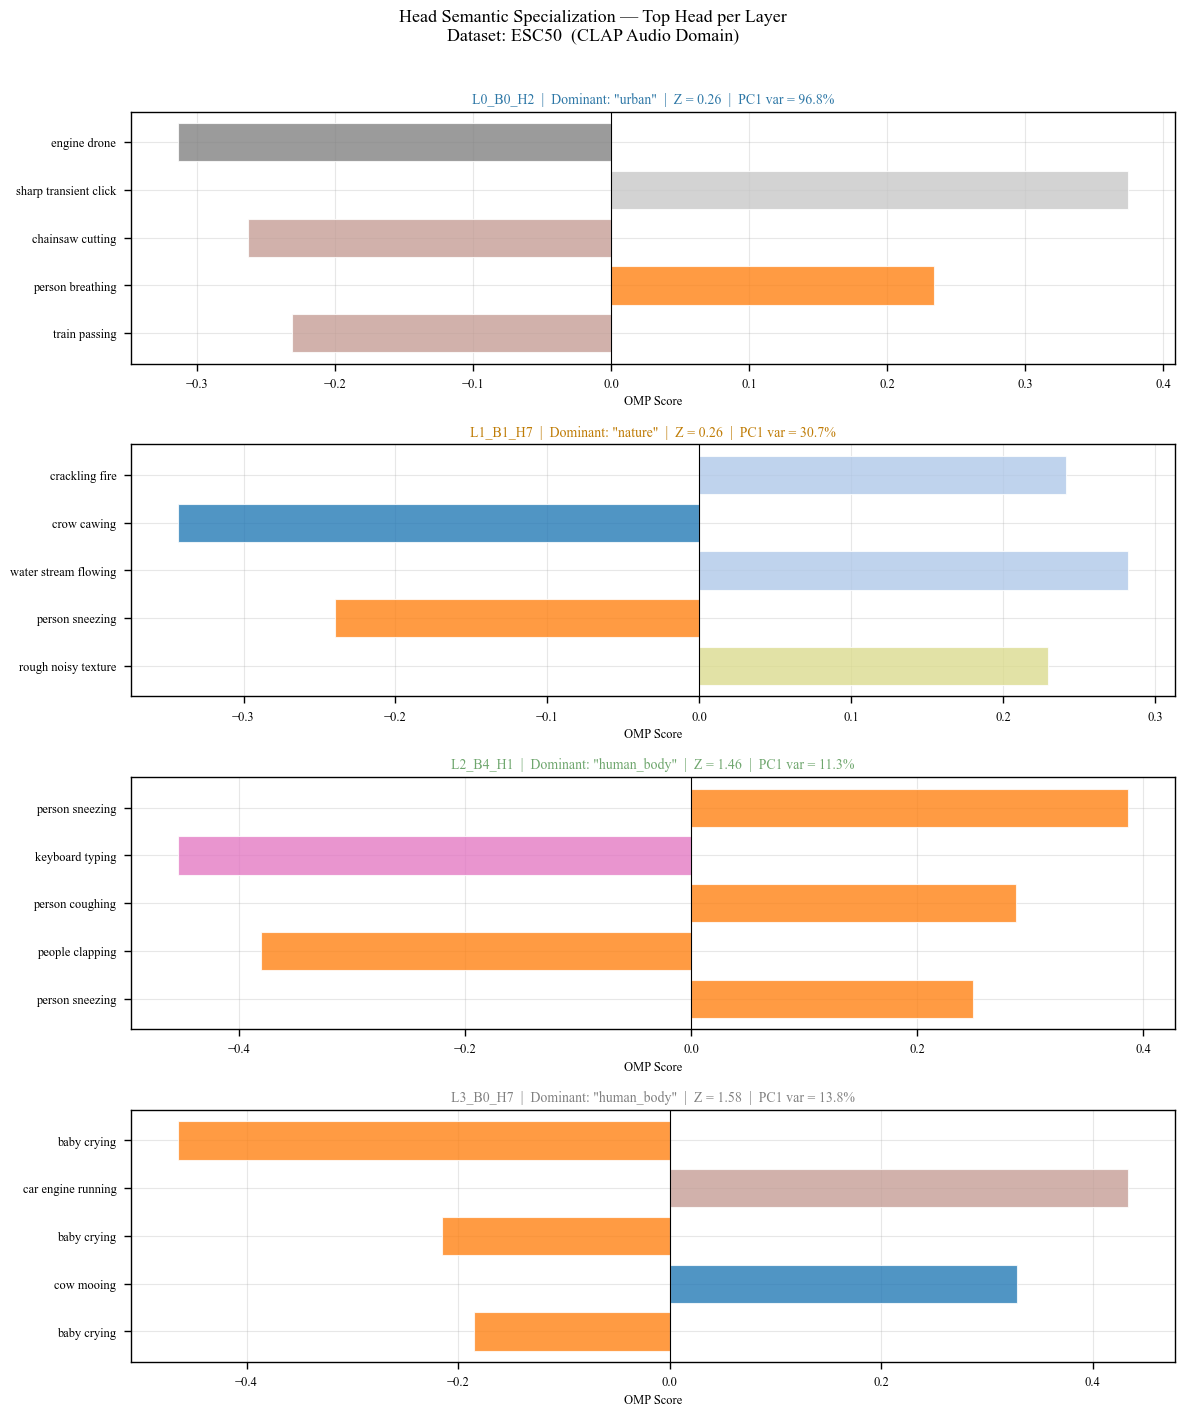

In [25]:
fig, axes = plt.subplots(4, 1, figsize=(12, 14))

cat_colors_map = {cat: plt.cm.tab20(i / len(cat_list))
                  for i, cat in enumerate(cat_list)}

for ax, layer_idx in zip(axes, range(4)):
    row  = sem_df[sem_df['layer'] == layer_idx].iloc[0]
    hid  = row['head_id']
    descs  = row['descriptions']
    cats   = row['categories']
    scores = row['scores']
    z      = row['coherence_z']
    dom    = row['dominant_cat']
    pc1v   = row['pc1_var']

    bar_colors = [cat_colors_map.get(c, 'gray') for c in cats]
    ax.barh(range(len(descs)), scores, color=bar_colors, alpha=0.78,
            edgecolor='white', linewidth=0.8)
    ax.set_yticks(range(len(descs)))
    ax.set_yticklabels(descs, fontsize=9)
    ax.set_xlabel('OMP Score', fontsize=9)
    ax.set_title(
        f'{hid}  |  Dominant: "{dom}"  |  Z = {z:.2f}  |  PC1 var = {pc1v*100:.1f}%',
        fontsize=10, fontweight='bold', color=layer_colors[layer_idx]
    )
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle(
    f'Head Semantic Specialization — Top Head per Layer\n'
    f'Dataset: {DATASET}  (CLAP Audio Domain)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('head_semantic_specialization.pdf', dpi=300, bbox_inches='tight')
plt.savefig('head_semantic_specialization.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.2 Distribuzione categoriale per layer

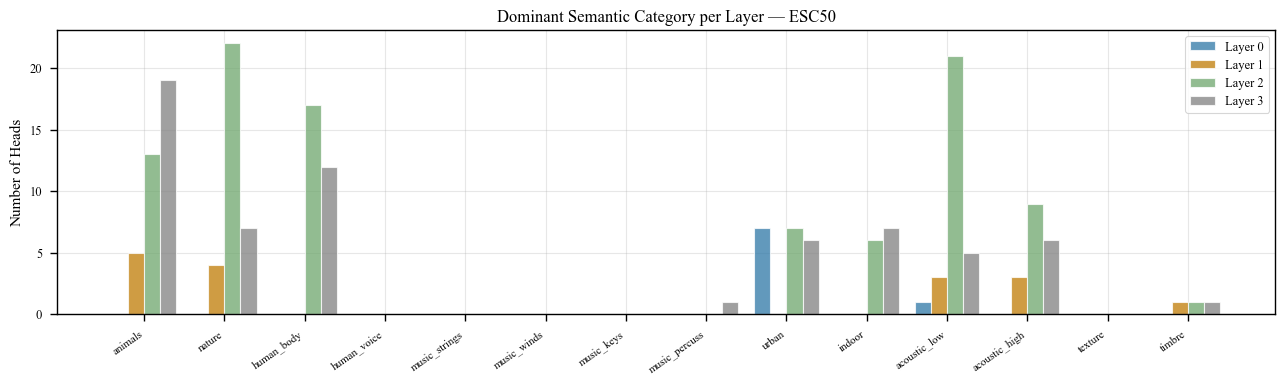

In [26]:
cat_counts = sem_df.groupby(['layer', 'dominant_cat']).size().unstack(fill_value=0)
cat_counts = cat_counts.reindex(columns=cat_list, fill_value=0)

fig, ax = plt.subplots(figsize=(13, 4))
x_cat = np.arange(len(cat_list))
bar_w = 0.2
for i, layer_idx in enumerate(range(4)):
    vals = cat_counts.loc[layer_idx] if layer_idx in cat_counts.index else [0] * len(cat_list)
    ax.bar(x_cat + i * bar_w, vals, bar_w,
           color=layer_colors[layer_idx], alpha=0.75,
           label=f'Layer {layer_idx}', edgecolor='white')

ax.set_xticks(x_cat + bar_w * 1.5)
ax.set_xticklabels(cat_list, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Number of Heads')
ax.set_title(f'Dominant Semantic Category per Layer — {DATASET}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.3 Heatmap categoria × testa (score OMP medio per categoria)

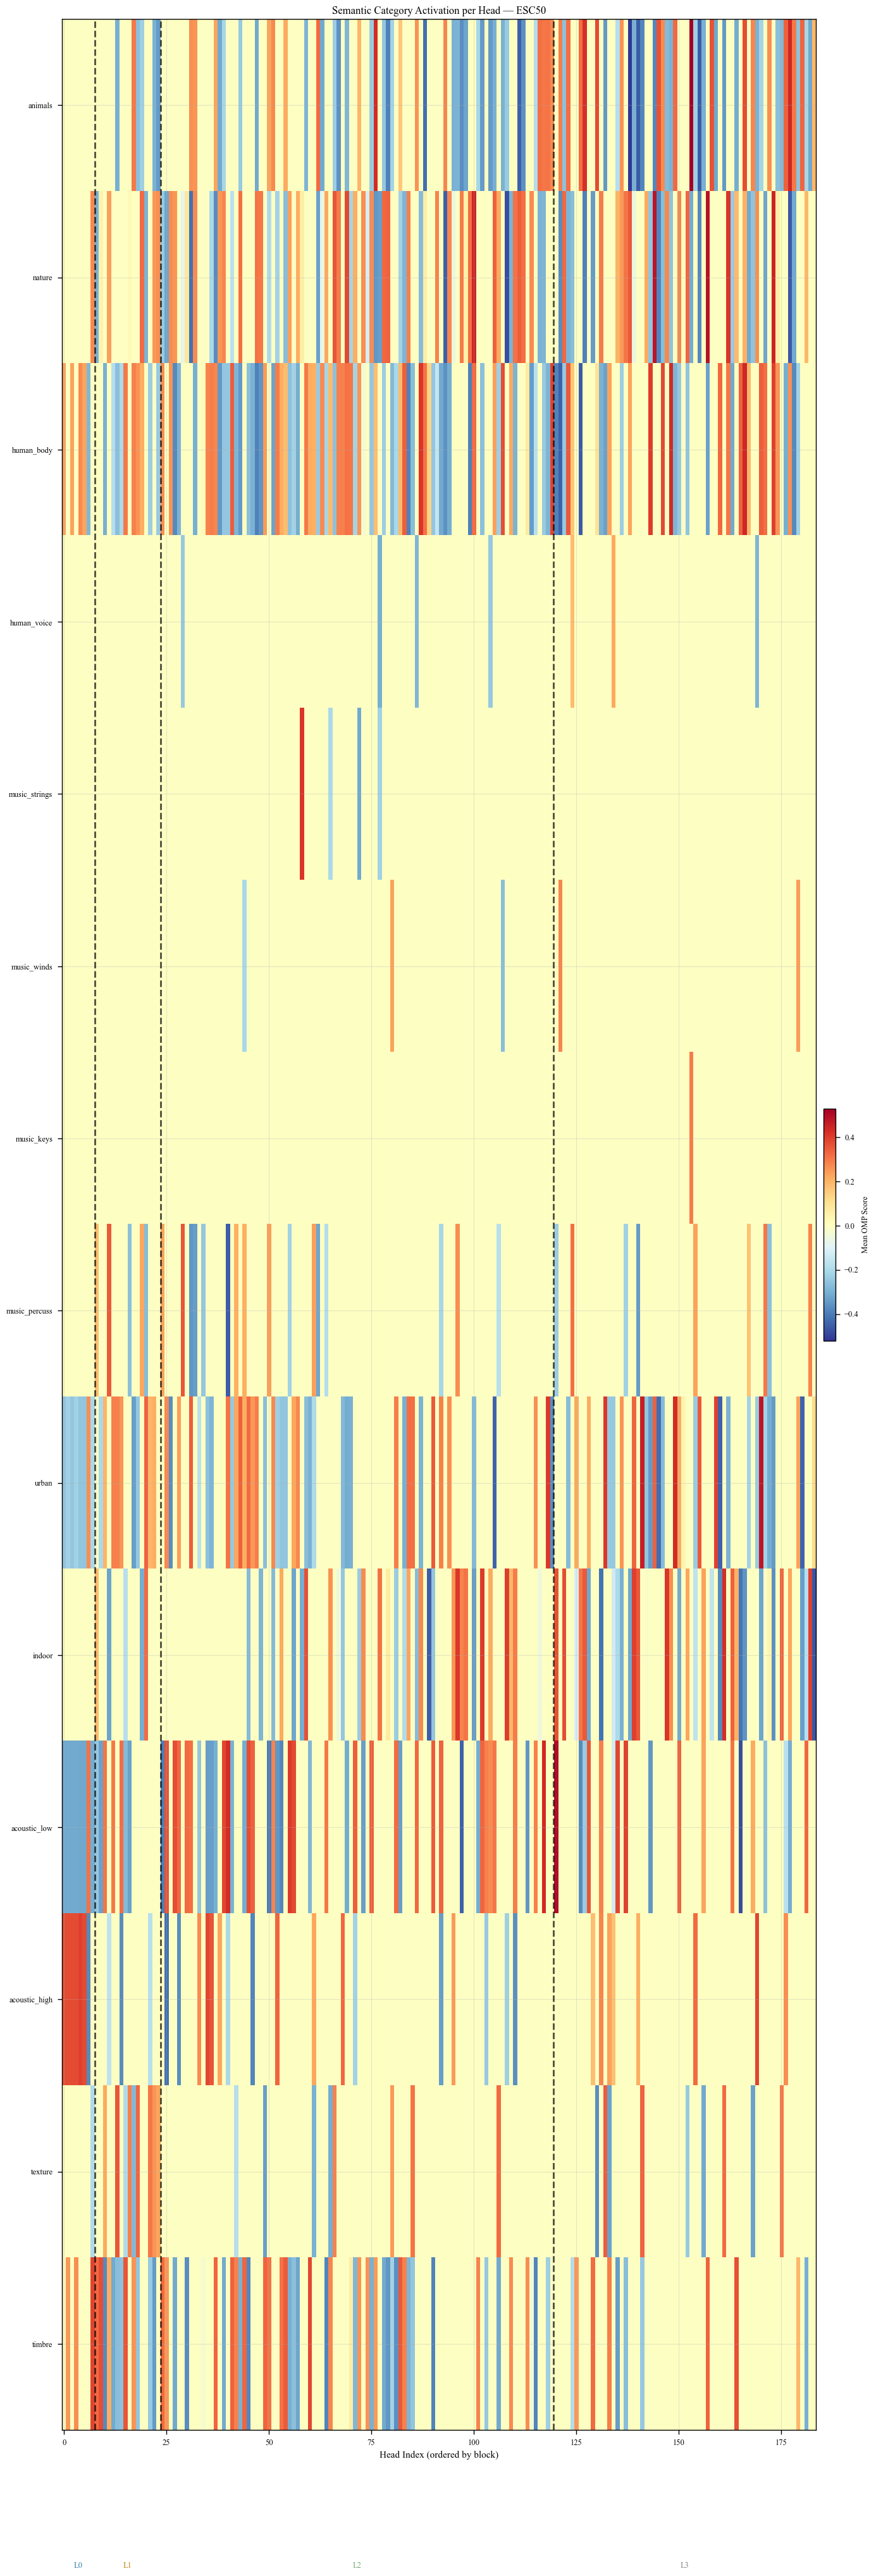

In [27]:
def category_score_vector(result):
    cat_scores = defaultdict(list)
    for cat, score in zip(result['categories'], result['scores']):
        cat_scores[cat].append(score)
    return {cat: float(np.mean(v)) for cat, v in cat_scores.items()}

rows_cat = []
for hid, res in head_semantic_results.items():
    cv  = category_score_vector(res)
    row = {
        'head_id':      hid,
        'layer':        int(hid.split('_')[0][1]),
        'global_block': sum(HTSAT_DEPTHS[:int(hid.split('_')[0][1])]) + int(hid.split('_')[1][1]),
    }
    for cat in cat_list:
        row[cat] = cv.get(cat, 0.0)
    rows_cat.append(row)

cat_score_df = pd.DataFrame(rows_cat).sort_values(['global_block', 'head_id'])
heatmap_data = cat_score_df[cat_list].values  # (n_heads, n_categories)

fig, ax = plt.subplots(figsize=(14, max(6, len(cat_score_df) * 0.22)))
im = ax.imshow(heatmap_data.T, aspect='auto', cmap='RdYlBu_r', interpolation='nearest')
ax.set_yticks(range(len(cat_list)))
ax.set_yticklabels(cat_list, fontsize=9)
ax.set_xlabel('Head Index (ordered by block)', fontsize=11)
ax.set_title(f'Semantic Category Activation per Head — {DATASET}',
             fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01).set_label('Mean OMP Score', fontsize=9)

# Linee di separazione per layer
cum_h = 0
for layer_idx, depth in enumerate(HTSAT_DEPTHS):
    n_heads_layer = depth * HTSAT_HEADS[layer_idx]
    cum_h += n_heads_layer
    if cum_h < len(cat_score_df):
        ax.axvline(x=cum_h - 0.5, color='black', linewidth=2, linestyle='--', alpha=0.7)
    ax.text(cum_h - n_heads_layer / 2 - 0.5, len(cat_list) + 0.3,
            f'L{layer_idx}', ha='center', fontsize=9, fontweight='bold',
            color=layer_colors[layer_idx], clip_on=False)

plt.tight_layout()
plt.savefig('category_heatmap_per_head.pdf', dpi=300, bbox_inches='tight')
plt.savefig('category_heatmap_per_head.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.4 Spearman Z-score vs. layer (la specializzazione aumenta in profondità?)

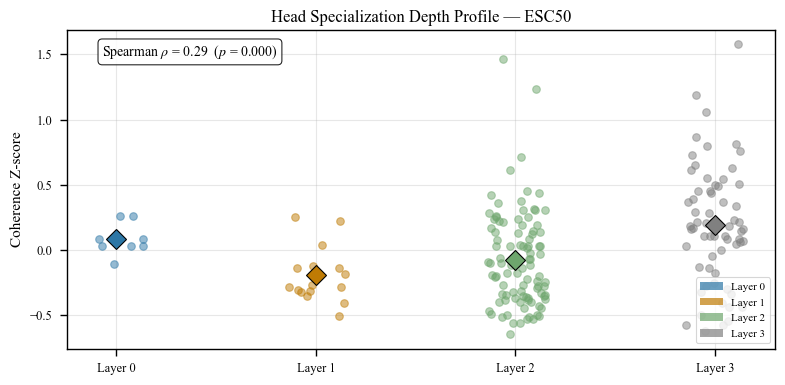

Spearman ρ (layer vs Z-score): 0.286  p = 0.0001


In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
for layer_idx in range(4):
    ld = sem_df[sem_df['layer'] == layer_idx]['coherence_z']
    ax.scatter(
        [layer_idx] * len(ld) + np.random.uniform(-0.15, 0.15, len(ld)),
        ld, c=layer_colors[layer_idx], alpha=0.5, s=30, zorder=3
    )
    ax.plot(layer_idx, ld.mean(), marker='D', color=layer_colors[layer_idx],
            markersize=10, markeredgecolor='black', markeredgewidth=0.8, zorder=4)

rho, pval = spearmanr(sem_df['layer'], sem_df['coherence_z'])
ax.text(0.05, 0.92,
        f'Spearman $\\rho$ = {rho:.2f}  ($p$ = {pval:.3f})',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

ax.set_xticks(range(4))
ax.set_xticklabels([f'Layer {i}' for i in range(4)])
ax.set_ylabel('Coherence Z-score')
ax.set_title(f'Head Specialization Depth Profile — {DATASET}',
             fontsize=12, fontweight='bold')
ax.legend(handles=legend_patches, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('specialization_depth_profile.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Spearman ρ (layer vs Z-score): {rho:.3f}  p = {pval:.4f}")

### 6.5 Activation profile per classe — top-N teste specializzate

Per ogni testa ad alto Z-score, mostra come i campioni di ogni classe
si proiettano sulla PC1: se la testa è davvero specializzata, le classi
semanticamente coerenti con la sua etichetta OMP dovrebbero avere
proiezioni sistematicamente più alte (o più basse).

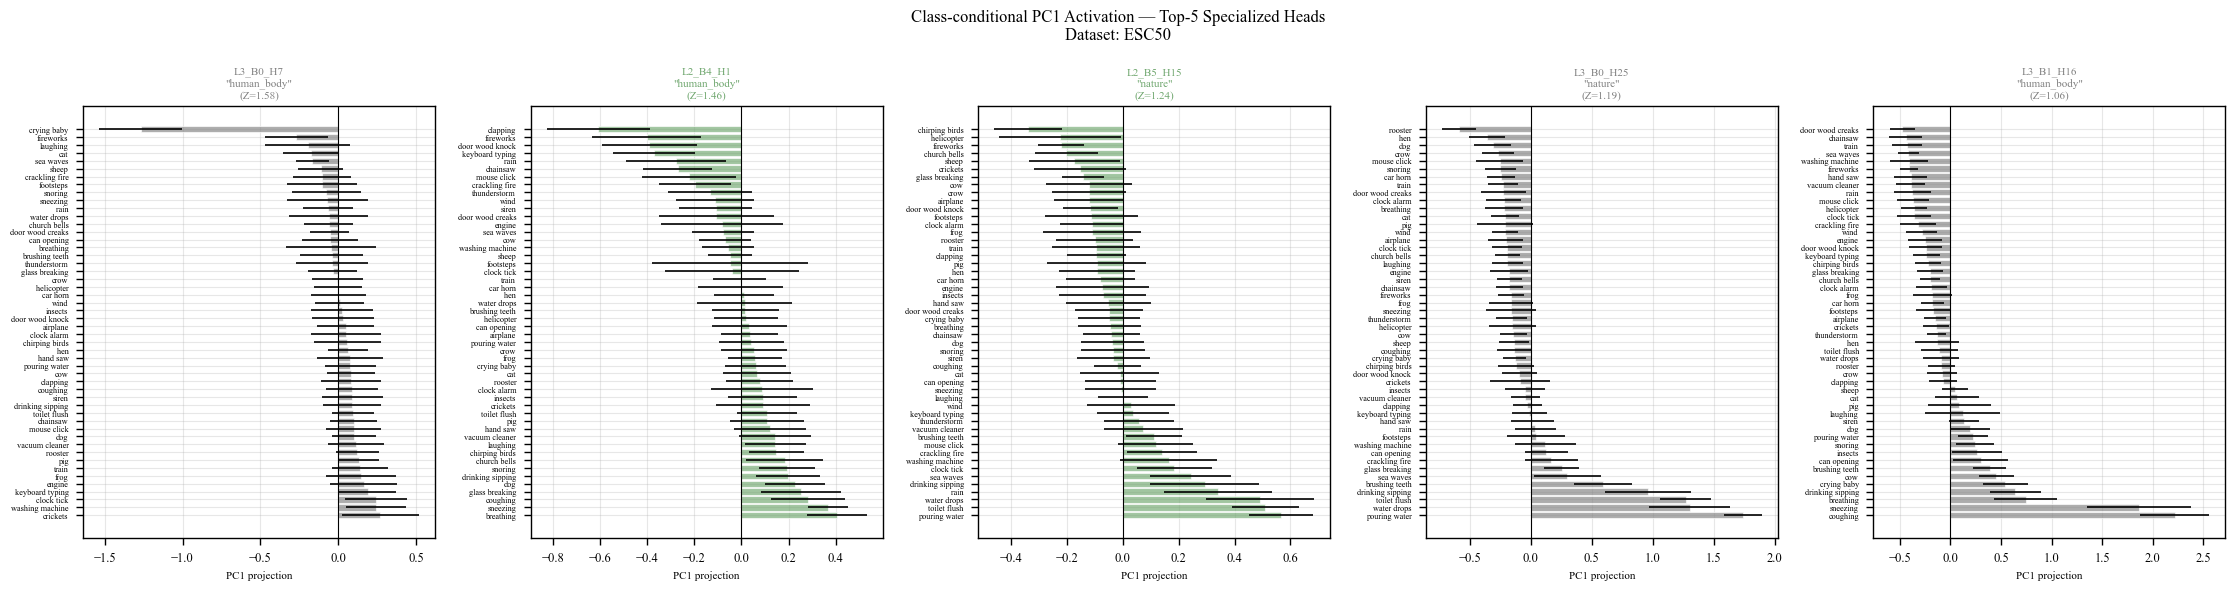

In [29]:
TOP_N_HEADS = 5
top_heads   = sem_df.head(TOP_N_HEADS)['head_id'].tolist()

fig, axes = plt.subplots(1, TOP_N_HEADS, figsize=(4.5 * TOP_N_HEADS, 6), sharey=False)
if TOP_N_HEADS == 1:
    axes = [axes]

for ax, hid in zip(axes, top_heads):
    X        = head_outputs_final[hid].numpy()
    pc1_proj = PCA(n_components=1).fit_transform(X)[:, 0]

    class_means = []
    class_stds  = []
    for c in range(n_classes):
        vals = pc1_proj[sample_labels == c]
        class_means.append(vals.mean())
        class_stds.append(vals.std())

    class_means = np.array(class_means)
    class_stds  = np.array(class_stds)
    order       = np.argsort(class_means)[::-1]

    res   = head_semantic_results[hid]
    title = f"{hid}\n\"{res['dominant_cat']}\"\n(Z={res['coherence_z']:.2f})"

    layer_idx_h = int(hid.split('_')[0][1])
    ax.barh(range(n_classes), class_means[order],
            xerr=class_stds[order],
            color=layer_colors[layer_idx_h],
            alpha=0.65, edgecolor='white', height=0.8)
    ax.set_yticks(range(n_classes))
    ax.set_yticklabels([CLASSES[i] for i in order], fontsize=6)
    ax.set_title(title, fontsize=8, fontweight='bold', color=layer_colors[layer_idx_h])
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlabel('PC1 projection', fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle(
    f'Class-conditional PC1 Activation — Top-{TOP_N_HEADS} Specialized Heads\n'
    f'Dataset: {DATASET}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('specialized_head_class_activation.pdf', dpi=300, bbox_inches='tight')
plt.savefig('specialized_head_class_activation.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.6 Head Similarity Matrix (spazio degli spettri di autovalori)

Confronto a coppie di tutte le teste basato sulla similarità coseno
del loro spettro PCA normalizzato, con clustering gerarchico.

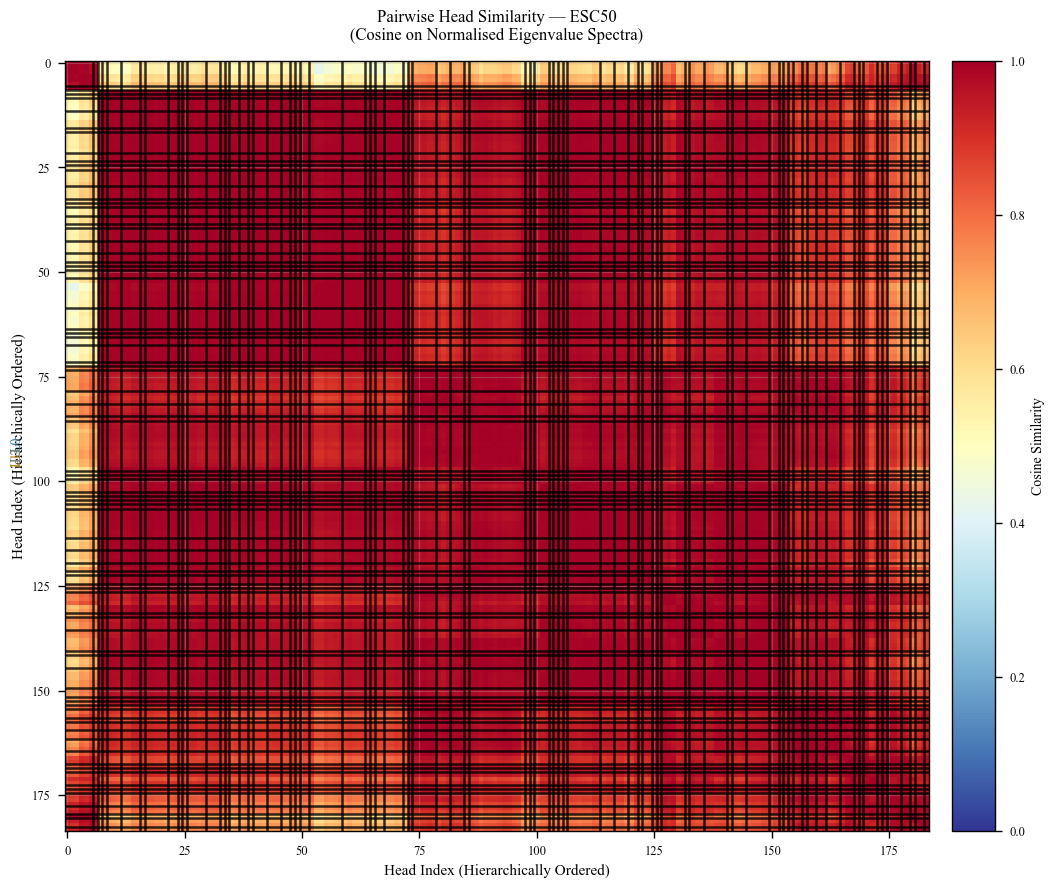

Within-layer similarity : 0.961
Cross-layer  similarity : 0.909
Ratio                   : 1.06x


In [30]:
# Costruisci spettri (troncati a 24 componenti, normalizzati)
spec_rows = []
for head_id in sorted(head_outputs_final.keys()):
    X  = head_outputs_final[head_id].numpy()
    pca_s = PCA(n_components=min(24, X.shape[1])).fit(X)
    ev = pca_s.explained_variance_
    sp = ev / ev.sum()
    if len(sp) < 24:
        sp = np.pad(sp, (0, 24 - len(sp)), 'constant')
    spec_rows.append(sp)

spectra_matrix    = np.array(spec_rows)                     # (n_heads, 24)
similarity_matrix = cosine_similarity(spectra_matrix)
linkage_matrix    = linkage(pdist(spectra_matrix), method='ward')
dendro            = dendrogram(linkage_matrix, no_plot=True)
ordered_indices   = dendro['leaves']

sim_ordered     = similarity_matrix[ordered_indices, :][:, ordered_indices]
head_ids_sorted = sorted(head_outputs_final.keys())
ordered_layers  = np.array([int(head_ids_sorted[i].split('_')[0][1])
                             for i in ordered_indices])

fig = plt.figure(figsize=(12, 10))
gs  = GridSpec(1, 2, width_ratios=[20, 1], wspace=0.05)
ax  = fig.add_subplot(gs[0])
im  = ax.imshow(sim_ordered, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=1)

current_layer = ordered_layers[0]
for i, layer in enumerate(ordered_layers):
    if layer != current_layer:
        ax.axhline(y=i - 0.5, color='black', linewidth=1.8, alpha=0.8)
        ax.axvline(x=i - 0.5, color='black', linewidth=1.8, alpha=0.8)
        current_layer = layer

for layer in range(4):
    mask = ordered_layers == layer
    if np.any(mask):
        start, end = np.where(mask)[0][0], np.where(mask)[0][-1]
        mid = (start + end) / 2
        ax.text(-len(ordered_indices) * 0.05, mid, f'L{layer}',
                rotation=90, va='center', ha='right',
                fontsize=10, fontweight='bold', color=layer_colors[layer])

ax.set_xlabel('Head Index (Hierarchically Ordered)', fontsize=11)
ax.set_ylabel('Head Index (Hierarchically Ordered)', fontsize=11)
ax.set_title(f'Pairwise Head Similarity — {DATASET}\n'
             f'(Cosine on Normalised Eigenvalue Spectra)',
             fontsize=12, fontweight='bold', pad=15)

cax  = fig.add_subplot(gs[1])
cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Cosine Similarity', fontsize=10)

plt.savefig('head_similarity_matrix.pdf', dpi=300, bbox_inches='tight')
plt.savefig('head_similarity_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistiche within / cross layer
within_sims, cross_sims = [], []
for l1 in range(4):
    idx_l1 = [i for i, hid in enumerate(head_ids_sorted)
               if int(hid.split('_')[0][1]) == l1]
    m_l1   = similarity_matrix[np.ix_(idx_l1, idx_l1)]
    within_sims.extend(m_l1[np.triu_indices_from(m_l1, k=1)])
    for l2 in range(l1 + 1, 4):
        idx_l2 = [i for i, hid in enumerate(head_ids_sorted)
                   if int(hid.split('_')[0][1]) == l2]
        cross_sims.extend(similarity_matrix[np.ix_(idx_l1, idx_l2)].flatten())

print(f"Within-layer similarity : {np.mean(within_sims):.3f}")
print(f"Cross-layer  similarity : {np.mean(cross_sims):.3f}")
print(f"Ratio                   : {np.mean(within_sims)/np.mean(cross_sims):.2f}x")

## 7. Final Summary

In [31]:
print("=" * 60)
print(f"FINAL SUMMARY — {DATASET}")
print("=" * 60)

rho_depth, pval_depth = spearmanr(sem_df['layer'], sem_df['coherence_z'])
rho_spec,  pval_spec  = spearmanr(sem_df['pca_99'] if 'pca_99' in sem_df.columns
                                  else id_df['pca_99'], sem_df['coherence_z']
                                  if len(sem_df) == len(id_df) else sem_df['coherence_z'])

print(f"\nSpearman ρ (layer vs Z-score)   : {rho_depth:.3f}  (p = {pval_depth:.4f})")
print(f"Within-layer head similarity    : {np.mean(within_sims):.3f}")
print(f"Cross-layer  head similarity    : {np.mean(cross_sims):.3f}")
print(f"Within/Cross ratio              : {np.mean(within_sims)/np.mean(cross_sims):.2f}x")

print(f"\nTop-10 teste per Z-score coerenza:")
print(sem_df[['head_id', 'layer', 'dominant_cat', 'coherence_z',
              'pc1_var']].head(10).to_string(index=False))

print("\nOutput files:")
for fname in [
    'htsat_DATASET_block_metrics.png',
    'panel_A_pca_components.png', 'panel_B_twonn.png', 'panel_C_mle.png',
    'panel_D_participation_ratio.png', 'panel_E_effective_rank.png',
    'panel_F_pc1_dominance.png', 'panel_G_boxplot.png',
    'class_activation_heatmap.png',
    'head_semantic_specialization.pdf/png',
    'category_distribution.png',
    'category_heatmap_per_head.pdf/png',
    'specialization_depth_profile.png',
    'specialized_head_class_activation.pdf/png',
    'head_similarity_matrix.pdf/png',
]:
    print(f"  - {fname}")

FINAL SUMMARY — ESC50

Spearman ρ (layer vs Z-score)   : 0.286  (p = 0.0001)
Within-layer head similarity    : 0.961
Cross-layer  head similarity    : 0.909
Within/Cross ratio              : 1.06x

Top-10 teste per Z-score coerenza:
  head_id  layer  dominant_cat  coherence_z  pc1_var
 L3_B0_H7      3    human_body     1.577244 0.138146
 L2_B4_H1      2    human_body     1.464484 0.113437
L2_B5_H15      2        nature     1.236646 0.148025
L3_B0_H25      3        nature     1.190981 0.199190
L3_B1_H16      3    human_body     1.059199 0.168799
L3_B1_H20      3    human_body     0.865645 0.169179
L3_B0_H27      3 acoustic_high     0.811794 0.117083
 L3_B1_H9      3         urban     0.799439 0.160598
 L3_B1_H1      3        nature     0.761276 0.175455
L3_B1_H19      3        nature     0.727769 0.204517

Output files:
  - htsat_DATASET_block_metrics.png
  - panel_A_pca_components.png
  - panel_B_twonn.png
  - panel_C_mle.png
  - panel_D_participation_ratio.png
  - panel_E_effective_ra